# Calibrating against an eddy-covariance reference

`snyder`, `chen97` and `wavelet` return an **uncalibrated** flux magnitude:
their $H = \rho c_p\, (a/\tau) z$-style scaling is only proportional to the
true flux, with a site- and setup-specific proportionality factor. The
standard SR practice is to fit a single block-scale factor $\alpha$ against
a co-located eddy-covariance (EC) system for a calibration period, then apply
that $\alpha$ operationally:

$$H_{cal} = \alpha \, H_{uncal}$$

This tutorial builds an EC-style reference from block-wise $w'T'$
covariances, fits $\alpha$ with `Calibration.from_reference`, and applies it
through `run_surface_renewal(..., alpha=...)` to obtain `H_cal` — and, since
this record carries `Rn` and `G`, the calibrated latent-heat residual
`LE_cal` as well.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from surface_renewal import run_surface_renewal, PipelineConfig

# A light, recessive plot style: hairline grid behind the data, no chart junk.
plt.rcParams.update({
    "figure.figsize": (9.0, 3.6),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": "#52514e",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "lines.linewidth": 1.8,
    "legend.frameon": False,
})

# Fixed series colors; each quantity keeps its color across all figures.
C_BLUE, C_AQUA, C_YELLOW, C_GREEN, C_VIOLET, C_INK = (
    "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#52514e",
)

## Synthetic input data

The tutorials are self-contained: instead of shipping a large raw data file,
each one generates a 4-hour, 10 Hz record with the structure the SR methods
look for — gradual warming **ramps** that end in a sharp temperature drop as
the heated air parcel is swept away and renewed. With your own data you would
skip this cell and pass a `DataFrame` (or a CSV/Parquet path) with columns
`T`, `u`, `v`, `w` and, optionally, `Rn` and `G` — see the
[quick start](../quickstart.md) for the input conventions. A stand-alone copy
of a similar generator ships with the repository as `scripts/make_synthetic.py`.

In [2]:
def make_synthetic(fs=10.0, hours=4.0, seed=42, wind=1.0):
    """Synthetic high-frequency record with surface-renewal ramp structure.

    Temperature follows the classic SR ramp — a slow rise ended by a sharp
    drop (60 s period) — whose amplitude grows toward "midday" and fades
    again (the ``env`` envelope). The wind components share part of the ramp
    signal so the record carries a realistic w'T' covariance and a well-posed
    friction velocity. ``wind`` scales all wind components (1.0 = breezy,
    small values = near-calm convective conditions).
    """
    rng = np.random.default_rng(seed)
    n = int(fs * 3600 * hours)
    t = np.arange(n) / fs

    # Convective "activity" envelope: ramps grow toward midday, then fade.
    env = 0.3 + 0.7 * np.sin(np.pi * t / t[-1])
    # Classic SR ramp: slow rise, sharp drop, 60 s period.
    ramp = 2.0 * ((t % 60.0) / 60.0) - 1.0

    T = 298.15 + 0.4 * env * ramp + 0.05 * rng.standard_normal(n)
    du = 0.5 * env * ramp + 0.5 * rng.standard_normal(n)  # streamwise gusts
    u = wind * (2.5 + du)
    v = wind * (0.1 + 0.5 * du + 0.3 * rng.standard_normal(n))
    w = wind * (0.2 * du + 0.15 * rng.standard_normal(n))

    idx = pd.Timestamp("2023-06-01 08:00") + pd.to_timedelta(t, unit="s")
    df = pd.DataFrame({"T": T, "u": u, "v": v, "w": w}, index=idx)

    # Radiation terms (W m^-2) so the latent-heat residual is exercised.
    solar = 400.0 + 200.0 * np.sin(np.pi * t / t[-1])
    df["Rn"] = solar + 20.0 * rng.standard_normal(n)
    df["G"] = 0.1 * solar + 5.0 * rng.standard_normal(n)
    return df

## Step 1 — run the pipeline uncalibrated

Exactly as in the [quickstart](01_quickstart.ipynb): without `alpha`,
`run_surface_renewal` returns `H_uncal` (and the uncalibrated residual
`LE_resid`).

In [3]:
df = make_synthetic()

cfg = PipelineConfig(fs=10.0, block="30min", method="snyder", rotation="double")
out = run_surface_renewal(df, cfg=cfg)
out[["H_uncal", "LE_resid", "passed"]].round(2)

,H_uncal,LE_resid,passed
2023-06-01 08:29:59.900,5.70,389.16,True
2023-06-01 08:59:59.900,9.70,449.64,True
2023-06-01 09:29:59.900,13.29,495.19,True
2023-06-01 09:59:59.900,15.35,519.90,True
2023-06-01 10:29:59.900,14.89,520.66,True
2023-06-01 10:59:59.900,13.32,495.41,True
2023-06-01 11:29:59.900,9.85,449.58,True
2023-06-01 11:59:59.900,5.86,389.09,True


## Step 2 — build the EC reference

In the field the reference comes from your EC processing chain (EddyPro,
easyflux, …) as one $H$ value per averaging block. Here we play the EC system
ourselves: the direct covariance estimate is
$H_{ec} = \rho c_p \, \overline{w'T'}$, with the primes denoting deviations
from the block means. The pipeline output conveniently carries the
per-block air density `rho` and specific heat `cp` it used.

One alignment detail: `Calibration.from_reference` matches the two series on
their **index intersection**, and the pipeline labels each block by its *last
sample time* while a plain `resample` labels by block *start* — so we
re-attach the pipeline's block index to the reference (the block partition is
identical).

In [4]:
# Per-block deviations from the block means, then the block-mean product w'T'.
dev = df[["w", "T"]] - df[["w", "T"]].resample("30min").transform("mean")
cov_wT = (dev["w"] * dev["T"]).resample("30min").mean()

ec_H = pd.Series(
    out["rho"].to_numpy() * out["cp"].to_numpy() * cov_wT.to_numpy(),
    index=out.index,           # align to the pipeline's block labels
    name="H_ec",
)
ec_H.round(2)

2023-06-01 08:29:59.900     3.25
2023-06-01 08:59:59.900     7.73
2023-06-01 09:29:59.900    12.60
2023-06-01 09:59:59.900    15.78
2023-06-01 10:29:59.900    15.48
2023-06-01 10:59:59.900    12.24
2023-06-01 11:29:59.900     7.37
2023-06-01 11:59:59.900     3.50
Name: H_ec, dtype: float64

## Step 3 — fit the block-scale factor α

`Calibration.from_reference` fits `reference ≈ alpha * model` with a robust
(outlier-trimmed) fit and, by default, **no intercept** — a pure gain keeps
low-flux periods unbiased. Restrict the fit to blocks that passed the
stability screens; on real data that filter matters much more than it does
here.

In [5]:
from surface_renewal import Calibration

ok = out["passed"]
cal = Calibration.from_reference(
    out.loc[ok, "H_uncal"], ec_H[ok], name="synthetic EC 2023-06-01",
)
cal

Calibration(alpha=0.9256773699702964, beta=0.0, name='synthetic EC 2023-06-01')

## Step 4 — apply it

Pass the fitted `Calibration` (or a bare float) back to
`run_surface_renewal`; the output gains `H_cal = alpha * H_uncal` and — since
`Rn` and `G` are available — the calibrated residual
`LE_cal = Rn − G − H_cal`.

In [6]:
out_cal = run_surface_renewal(df, cfg=cfg, alpha=cal)
out_cal[["H_uncal", "H_cal", "LE_resid", "LE_cal", "passed"]].round(2)

,H_uncal,H_cal,LE_resid,LE_cal,passed
2023-06-01 08:29:59.900,5.70,5.27,389.16,389.59,True
2023-06-01 08:59:59.900,9.70,8.98,449.64,450.36,True
2023-06-01 09:29:59.900,13.29,12.30,495.19,496.17,True
2023-06-01 09:59:59.900,15.35,14.21,519.90,521.04,True
2023-06-01 10:29:59.900,14.89,13.78,520.66,521.76,True
2023-06-01 10:59:59.900,13.32,12.33,495.41,496.40,True
2023-06-01 11:29:59.900,9.85,9.12,449.58,450.31,True
2023-06-01 11:59:59.900,5.86,5.43,389.09,389.52,True


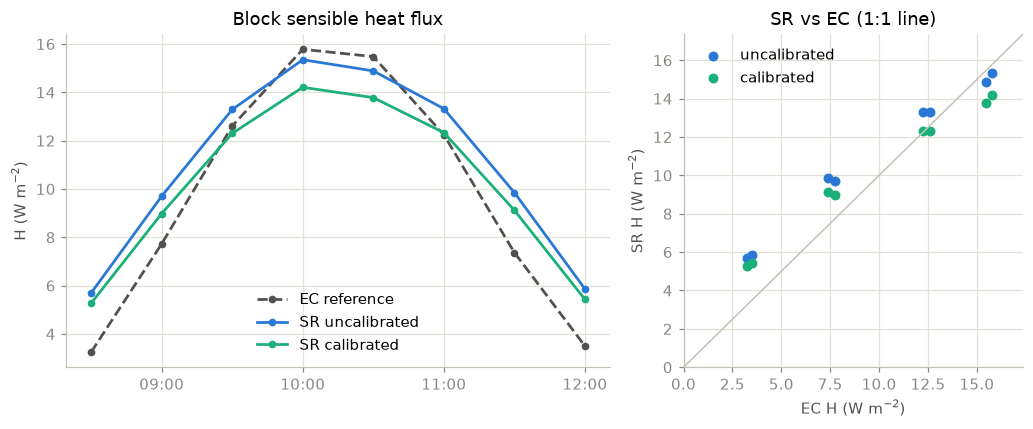

In [7]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(9.5, 4.0), width_ratios=[1.6, 1.0]
)

ax1.plot(ec_H.index, ec_H, color=C_INK, ls="--", marker="o", ms=4,
         label="EC reference")
ax1.plot(out.index, out["H_uncal"], color=C_BLUE, marker="o", ms=4,
         label="SR uncalibrated")
ax1.plot(out_cal.index, out_cal["H_cal"], color=C_AQUA, marker="o", ms=4,
         label="SR calibrated")
ax1.set_ylabel("H (W m$^{-2}$)")
ax1.set_title("Block sensible heat flux")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.xaxis.set_major_locator(mdates.HourLocator())
ax1.legend()

lims = (0.0, float(max(ec_H.max(), out["H_uncal"].max())) * 1.1)
ax2.plot(lims, lims, color="#c3c2b7", lw=1.0)  # 1:1 line
ax2.scatter(ec_H, out["H_uncal"], color=C_BLUE, s=30, label="uncalibrated")
ax2.scatter(ec_H, out_cal["H_cal"], color=C_AQUA, s=30, label="calibrated")
ax2.set_xlim(lims); ax2.set_ylim(lims)
ax2.set_xlabel("EC H (W m$^{-2}$)")
ax2.set_ylabel("SR H (W m$^{-2}$)")
ax2.set_title("SR vs EC (1:1 line)")
ax2.legend(loc="upper left")

fig.tight_layout()
plt.show()

The calibration pulls the SR points onto the 1:1 line. The correction is
small here because the synthetic record was built to be well-behaved; on real
sites $\alpha$ routinely differs from 1 by tens of percent and depends on
sensor height, canopy and averaging choices.

## Practical notes

- **Fit on screened blocks only** (`passed == True`), and only over a period
  where the EC reference itself is trustworthy.
- **Refit when the site changes** — canopy growth, sensor height changes, or
  a new season generally shift $\alpha$.
- **A bare float works too**: `run_surface_renewal(df, cfg=cfg, alpha=1.15)`
  is equivalent to a `Calibration(alpha=1.15)` with no offset.
- **Sign conventions**: `chen97` and `fvs` fluxes carry the sign of
  $S_3(\tau^*)$ (negative over daytime warming ramps — see the
  [method comparison](02_method_comparison.ipynb)); a fitted $\alpha$ absorbs
  that sign automatically.
- `fvs` and `castellvi` need **no** $\alpha$ — if no EC tower is available,
  prefer them (see the [method-selection guide](../methods.md)).